In [101]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

In [145]:
def filtpadding(coeffs, fftSize):
  out = np.zeros(fftSize)
  out[0:len(coeffs)] = coeffs[:]
  return out
def filteranalfft(ffcoef,fbcoef = None, fftSize = 128):
  ffcoeffspad = filtpadding(ffcoef, fftSize)
  if fbcoef is None:
    fbcoef = np.array([1])
  fbcoeffspad = filtpadding(fbcoef, fftSize)
  H = np.fft.fft(ffcoeffspad)
  H /= np.fft.fft(fbcoeffspad)
  posfreq = fftSize // 2
  nnfi = np.zeros(posfreq,dtype=complex)
  #only positive
  nnfi[:] = H[0:posfreq]
  gains = np.zeros(posfreq)
  phases = np.zeros(posfreq)
  # amplitudes
  gains = np.abs(nnfi)
  # phases
  phases = np.angle(nnfi)
  nnfb = len(nnfi)
  f = np.linspace(0,nnfb / fftSize,num = posfreq)

  plt.xlabel('Frequency (Hz)')
  plt.ylabel('Amplitude')
  plt.plot(f,gains)
  plt.grid(True)
  plt.show()
  plt.plot(f,phases)
  plt.xlabel('Frequency (Hz)')
  plt.ylabel('Phase')

  plt.grid(True)
  plt.show()
  return


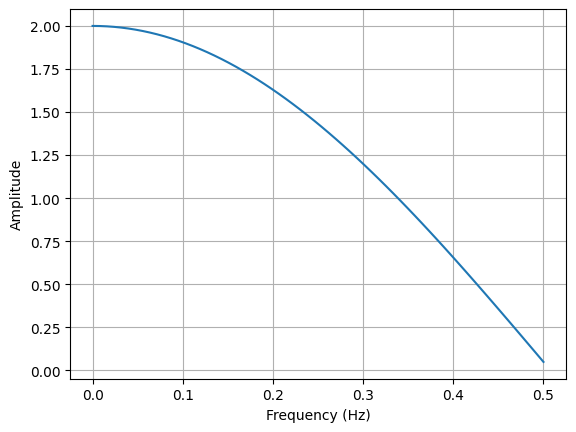

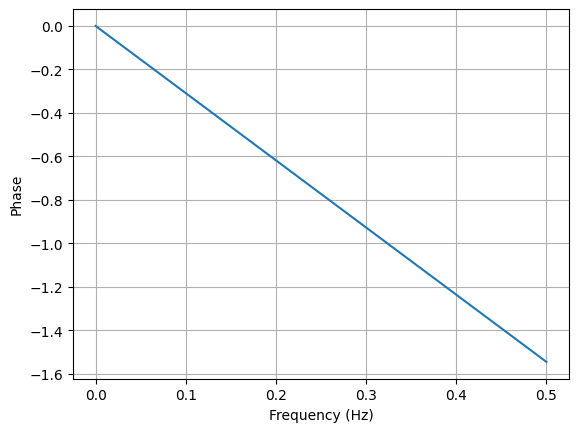

In [146]:
ff = np.array([1,1])
filteranalfft(ff)